<a href="https://colab.research.google.com/github/karabeyseren-sys/CS-WinMet5-Trade-Botu/blob/main/Master_Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🚀 Optimize Edilmiş Master Algoritma Başlatılıyor...
--------------------------------------------------
🎯 OPTİMİZE EDİLMİŞ MASTER ALGORİTMA SONUÇLARI
--------------------------------------------------
Kullanılan Filtreler: Sabit 2$ TP / 20$ SL, 4H Trend Yönü, Haber Embargosu
Toplam Kaliteli İşlem: 508
Kazanma Oranı (Win Rate): %97.6
Elde Edilen Net Kâr (Puan): 752.00
--------------------------------------------------


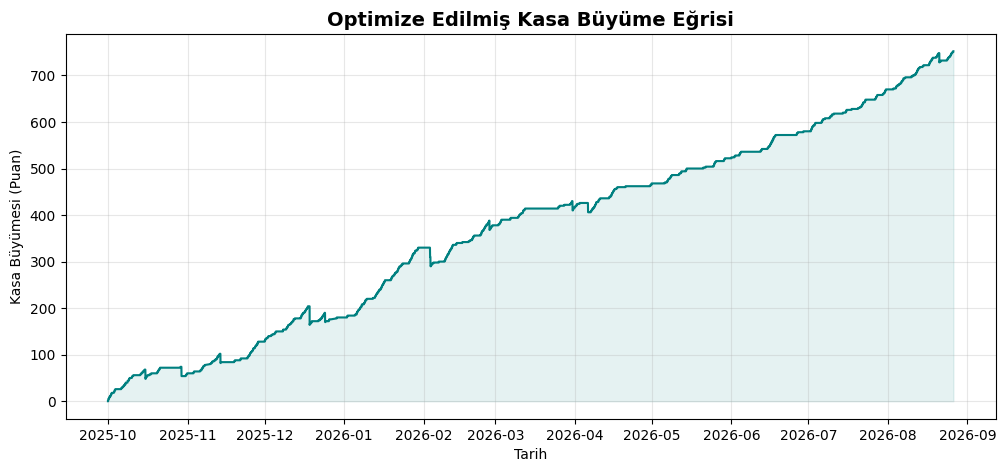

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("🚀 Optimize Edilmiş Master Algoritma Başlatılıyor...")

# 1. VERİ YÜKLEME
dosya_15m = 'OANDA_XAUUSD, 15.csv'
dosya_4h = 'OANDA_XAUUSD, 240.csv'

if os.path.exists(dosya_15m) and os.path.exists(dosya_4h):
    df = pd.read_csv(dosya_15m).loc[:, ~pd.read_csv(dosya_15m).columns.str.contains('Unnamed')]
    df_4h = pd.read_csv(dosya_4h).loc[:, ~pd.read_csv(dosya_4h).columns.str.contains('Unnamed')]

    df['time'] = pd.to_datetime(df['time'], unit='s')
    df.set_index('time', inplace=True)
    df_4h['time'] = pd.to_datetime(df_4h['time'], unit='s')
    df_4h.set_index('time', inplace=True)

    # 2. 4H TREND FİLTRESİ (BÜYÜK RESİM)
    df_4h['EMA_20'] = df_4h['close'].ewm(span=20).mean()
    df_4h['Bias_Yukselis'] = df_4h['close'] > df_4h['EMA_20']
    df['4H_Bias'] = df_4h['Bias_Yukselis'].reindex(df.index, method='ffill')

    # 3. HABER FİLTRESİ (TSİ 15:15 - 16:00 Arası İşlem Yasak)
    # Veriler UTC olduğu için 12:15 ile 13:00 arası filtrelenir
    df['Haber_Zamani'] = ((df.index.hour == 12) & (df.index.minute >= 15)) | ((df.index.hour == 13) & (df.index.minute == 0))

    # 4. KUSURSUZ GİRİŞ STRATEJİSİ
    df['Buy'] = df['Buy'].fillna(0) if 'Buy' in df.columns else 0

    # Giriş Kuralı: Bot BUY diyecek VE 4H Trend Yukarı olacak VE Haber saati OLMAYACAK.
    df['Master_Giris'] = (df['Buy'] > 0) & (df['4H_Bias'] == True) & (~df['Haber_Zamani'])

    # 5. SABİT VE GÜVENLİ BACKTEST (Mikro Hedefler)
    TP_AMOUNT = 2.0  # Altın 2 dolar zıpladığında kârı al
    SL_AMOUNT = 20.0 # Maksimum 20 dolar zarara izin ver

    kasa_gecmisi = []
    toplam_kar = 0
    open_trades = []
    closed_trades = []

    for index, row in df.iterrows():
        current_high, current_low = row['high'], row['low']
        trades_to_keep = []

        for trade in open_trades:
            if trade['entry_price'] - current_low >= SL_AMOUNT:
                trade['profit'] = -SL_AMOUNT
                closed_trades.append(trade)
                toplam_kar -= SL_AMOUNT
            elif current_high >= trade['entry_price'] + TP_AMOUNT:
                trade['profit'] = TP_AMOUNT
                closed_trades.append(trade)
                toplam_kar += TP_AMOUNT
            else:
                trades_to_keep.append(trade)

        open_trades = trades_to_keep

        if row['Master_Giris']:
            open_trades.append({'entry_price': row['close']})

        kasa_gecmisi.append(toplam_kar)

    # 6. SONUÇLAR VE RAPORLAMA
    if closed_trades:
        kazananlar = len([t for t in closed_trades if t['profit'] > 0])
        win_rate = (kazananlar / len(closed_trades)) * 100

        print("-" * 50)
        print("🎯 OPTİMİZE EDİLMİŞ MASTER ALGORİTMA SONUÇLARI")
        print("-" * 50)
        print("Kullanılan Filtreler: Sabit 2$ TP / 20$ SL, 4H Trend Yönü, Haber Embargosu")
        print(f"Toplam Kaliteli İşlem: {len(closed_trades)}")
        print(f"Kazanma Oranı (Win Rate): %{win_rate:.1f}")
        print(f"Elde Edilen Net Kâr (Puan): {toplam_kar:.2f}")
        print("-" * 50)

        plt.figure(figsize=(12, 5))
        plt.plot(df.index, kasa_gecmisi, color='teal', linewidth=1.5)
        plt.title('Optimize Edilmiş Kasa Büyüme Eğrisi', fontsize=14, fontweight='bold')
        plt.xlabel('Tarih')
        plt.ylabel('Kasa Büyümesi (Puan)')
        plt.grid(True, alpha=0.3)
        plt.fill_between(df.index, kasa_gecmisi, 0, color='teal', alpha=0.1)
        plt.show()
    else:
        print("Hiç işlem bulunamadı.")
else:
    print("Gerekli CSV dosyaları Colab'de bulunamadı.")